Total AMP dosage: 2160.0 µg mL⁻¹  (4320.0 µg total)



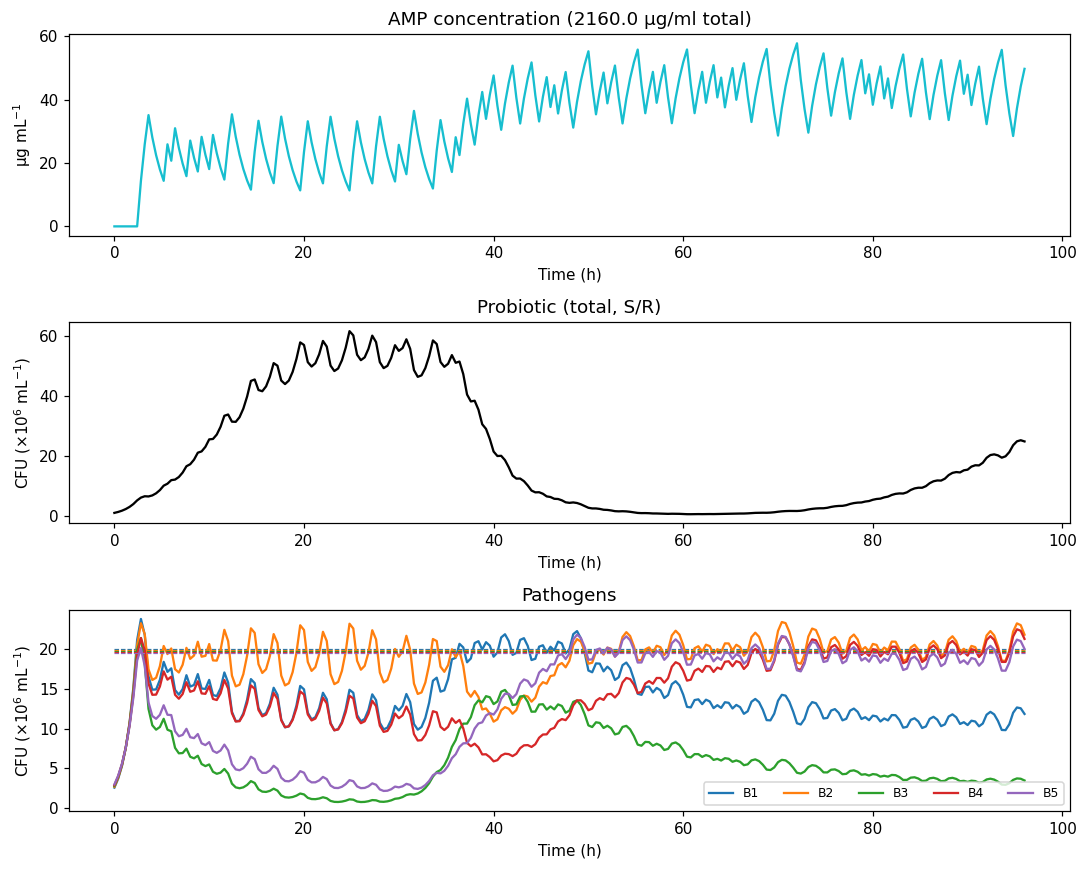

=== KPI ===
P-AUC: 0.131
LR1: -0.66 log10
LR2: -0.91 log10
LR3: -0.10 log10
LR4: -0.86 log10
LR5: -0.82 log10


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

# ──────────────────────────────────────────────────────────────
# 0. 參數設定（保持原值）
# ──────────────────────────────────────────────────────────────
n = 5
k   = np.array([1.1, 1.06, 1.02, 0.98, 0.94])              # h⁻¹
K   = np.array([1.8e8, 1.75e8, 1.70e8, 1.65e8, 1.60e8])
B0_S = 1 * np.array([2.6e6, 2.7e6, 2.8e6, 2.9e6, 3.0e6])   # 初始敏感株
mu   = np.array([1.8e-7, 1.7e-7, 1.6e-7, 1.5e-7, 1.4e-7])

gamma_S = np.array([0.035, 0.032, 0.038, 0.031, 0.033])
rho      = np.array([0.50, 0.52, 0.54, 0.56, 0.58])
gamma_R  = gamma_S * (1 - rho)
eta      = np.array([0.96, 0.93, 0.98, 0.90, 0.95])

alpha = np.full((n, n), 0.05); np.fill_diagonal(alpha, 1.0)
beta  = np.full(n, 0.10)

# Probiotic 兩亞群
kP, KP = 0.8, 1.5e8
gamma_P_S = 0.018
rho_P     = 0.40
gamma_P_R = gamma_P_S * (1 - rho_P)
eta_P     = 0.95
mu_P      = 1e-7
P0_S, P0_R = 1.0e6, 0.0

# AMP 與控制參數
lam       = 0.50                # 自然衰減
u_max     = 18.0                # 每次投藥 (µg mL⁻¹)
dt_detect = 1/6                 # 偵測週期 (10 min)
T_thr     = 0.5 * np.array([4e7, 3.975e7, 3.95e7, 3.925e7, 3.9e7])

# 模擬時間
t_end, dt = 96.0, 0.4
steps     = int(t_end / dt) + 1
times     = np.linspace(0, t_end, steps)

# ──────────────────────────────────────────────────────────────
# 1. 初始狀態與紀錄陣列
# ──────────────────────────────────────────────────────────────
B_S, B_R = B0_S.copy(), np.zeros(n)
P_S, P_R = P0_S, P0_R
C = 0.0

B_hist      = np.zeros((steps, n))
P_S_hist    = np.zeros(steps)
P_R_hist    = np.zeros(steps)
C_hist      = np.zeros(steps)

next_detect = 0.0
dose_count  = 0

# ──────────────────────────────────────────────────────────────
# 2. 主要迴圈
# ──────────────────────────────────────────────────────────────
for idx, t in enumerate(times):
    # 紀錄
    B_hist[idx]   = B_S + B_R
    P_S_hist[idx] = P_S
    P_R_hist[idx] = P_R
    C_hist[idx]   = C
    
    # --- 閾值控制器 (每 dt_detect 觸發一次) ---
    if t >= next_detect - 1e-12:
        if np.any(B_S + B_R > T_thr):
            C += u_max
            dose_count += 1
        next_detect += dt_detect
    
    # --- 動態方程 ---
    P_tot = P_S + P_R
    comp  = (alpha @ (B_S + B_R)) + beta * P_tot      # 競爭項
    
    dB_S = k  * B_S * (1 - comp / K) - gamma_S * C * B_S - mu  * B_S
    dB_R = eta * k * B_R * (1 - comp / K) - gamma_R * C * B_R + mu  * B_S
    
    dP_S = kP * P_S * (1 - P_tot / KP) - gamma_P_S * C * P_S - mu_P * P_S
    dP_R = eta_P * kP * P_R * (1 - P_tot / KP) - gamma_P_R * C * P_R + mu_P * P_S
    
    dC   = -lam * C
    
    # Euler 更新
    B_S += dB_S * dt;  B_R += dB_R * dt
    P_S += dP_S * dt;  P_R += dP_R * dt
    C   += dC   * dt
    
    # 非負截斷
    B_S = np.clip(B_S, 0, None); B_R = np.clip(B_R, 0, None)
    P_S = max(P_S, 0.0); P_R = max(P_R, 0.0)
    C   = max(C, 0.0)

# ──────────────────────────────────────────────────────────────
# 3. 劑量統計
# ──────────────────────────────────────────────────────────────
V =  2 # mL
total_dosage = u_max * dose_count          # µg mL⁻¹
total_mass   = total_dosage * V            # µg

print(f"Total AMP dosage: {total_dosage:.1f} µg mL⁻¹  ({total_mass:.1f} µg total)\n")

# ──────────────────────────────────────────────────────────────
# 4. 圖形輸出
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(times, C_hist, color='tab:cyan')
plt.title(F'AMP concentration ({total_dosage:.1f} µg/ml total)')
plt.xlabel('Time (h)'); plt.ylabel('CFU (×10$^{6}$ mL$^{-1}$)')
plt.ylabel('µg mL$^{-1}$')

plt.subplot(3, 1, 2)
plt.plot(times, (P_S_hist + P_R_hist) / 1e6, 'k', label='P_total')
plt.xlabel('Time (h)'); plt.ylabel('CFU (×10$^{6}$ mL$^{-1}$)')
plt.title('Probiotic (total, S/R)')

plt.subplot(3, 1, 3)
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for i in range(n):
    plt.plot(times, B_hist[:, i] / 1e6, color=colors[i], label=f'B{i+1}')
    plt.hlines(T_thr[i] / 1e6, 0, t_end, colors=colors[i], linestyles='dashed', lw=0.8)
plt.xlabel('Time (h)'); plt.ylabel('CFU (×10$^{6}$ mL$^{-1}$)')
plt.title('Pathogens')
plt.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────
# 5. KPI 計算
# ──────────────────────────────────────────────────────────────
P_hist = P_S_hist + P_R_hist
P_AUC  = np.trapz(P_hist / KP, times) / t_end
LR     = np.log10(B_hist[0] / np.clip(B_hist[-1], 1, None))

print("=== KPI ===")
print(f"P-AUC: {P_AUC:.3f}")
for i, lr in enumerate(LR, 1):
    print(f"LR{i}: {lr:.2f} log10")


In [14]:
def run_case(B0, k_arr, gamma_arr, rho_arr, mu_arr,
             u_max, T_thr,
             t_end=96.0, dt=0.4):
    """
    input
      B0, k_arr, gamma_arr, rho_arr, mu_arr :  長度 5 的 np.ndarray
      u_max  : 單次劑量上限  (µg mL⁻¹)
      T_thr  : 長度 5 閾值向量 (CFU mL⁻¹)
    output
      row = [ 25 個 feature , P_AUC , LR1 … LR5 ]  ← 共 31 欄
    """
    # -------- 常數 (益生菌、λ 等) ------------- 
    n = 5
    K  = np.array([1.8e8,1.75e8,1.70e8,1.65e8,1.60e8])
    alpha = np.full((n,n),0.05); np.fill_diagonal(alpha,1)
    beta  = np.full(n,0.10)
    kP, KP = 0.8, 1.5e8
    gamma_P_S, rho_P = 0.018, 0.40
    gamma_P_R = gamma_P_S*(1-rho_P)
    eta_P, mu_P = 0.95, 1e-7
    P0_S, P0_R  = 1e6, 0.0
    lam = 0.50
    dt_detect = 1/6            # 10 min
    
    # -------- 初始狀態 ------------------------
    B_S, B_R = B0.copy(), np.zeros(n)
    P_S, P_R = P0_S, P0_R
    C = 0.0
    next_detect = 0.0
    P_auc_acc   = 0.0
    eta   = np.array([0.96,0.93,0.98,0.90,0.95])
    gamma_R = gamma_arr*(1-rho_arr)
    
    steps = int(t_end/dt)+1
    for s in range(steps):
        t = s*dt
        # -- dosing rule --
        if t >= next_detect-1e-12:
            if np.any(B_S+B_R > T_thr):
                C += u_max
            next_detect += dt_detect
        # -- ODEs --
        P_tot = P_S+P_R
        comp = (alpha@(B_S+B_R))+beta*P_tot
        
        dB_S = k_arr*B_S*(1-comp/K) - gamma_arr*C*B_S - mu_arr*B_S
        dB_R = eta*k_arr*B_R*(1-comp/K) - gamma_R*C*B_R + mu_arr*B_S
        dP_S = kP*P_S*(1-P_tot/KP) - gamma_P_S*C*P_S - mu_P*P_S
        dP_R = eta_P*kP*P_R*(1-P_tot/KP) - gamma_P_R*C*P_R + mu_P*P_S
        dC   = -lam*C
        
        B_S += dB_S*dt;  B_R += dB_R*dt
        P_S += dP_S*dt;  P_R += dP_R*dt
        C   += dC*dt
        
        B_S = np.clip(B_S,0,None); B_R=np.clip(B_R,0,None)
        P_S = max(P_S,0); P_R=max(P_R,0); C=max(C,0)
        
        P_auc_acc += (P_S+P_R)*dt
    # -------- KPI ------------
    P_AUC = P_auc_acc/(KP*t_end)
    LR    = np.log10(B0/np.clip(B_S+B_R,1,None))
    
    return np.concatenate([B0,k_arr,gamma_arr,rho_arr,mu_arr,
                           [u_max],T_thr,
                           [P_AUC],LR])



# -------------  put run_case() here (上一訊息函式) ---------------
import numpy as np, pandas as pd, itertools, csv, multiprocessing as mp
from scipy.stats import qmc              # ← 只改這一行
# ----------- 放 run_case() 定義 --------------------------

# --- 1) 產生 500 條 bio 連續向量 --------------------------
sampler = qmc.LatinHypercube(d=15, seed=0)   # 15 維 LHS
lhs_mat = sampler.random(n=500)      
                                 # 15 = 5×3

def scale(v, lo, hi): return lo + v*(hi-lo)

B0_lo, B0_hi = 0.6*B0_S, 1.4*B0_S
k_lo,  k_hi  = 0.8*k,     1.2*k
g_lo,  g_hi  = 0.8*gamma_S, 1.2*gamma_S

bio_vecs = []
for row in lhs_mat:
    ptr = 0
    B0  = scale(row[ptr:ptr+5],  B0_lo, B0_hi); ptr += 5
    k_v = scale(row[ptr:ptr+5],  k_lo,  k_hi);  ptr += 5
    g_v = scale(row[ptr:ptr+5],  g_lo,  g_hi);  ptr += 5
    bio_vecs.append((B0, k_v, g_v))


mu_fac  = [0.8, 1.2]
rho_add = [0.0, 0.05]
# --- control grid -------------------------------------------------
u_grid  = np.arange(10, 31, 2)                    # 11 levels

thr_levels = 0.4 * 2.0e7 * 1.26**np.arange(10)    # 10 log levels

from scipy.stats import qmc                       # Sobol 5-D
sob = qmc.Sobol(d=5, scramble=True, seed=42)
T_unit = sob.random_base2(m=4)[:10]               # 16 → 取前 10
T_vecs = thr_levels[(T_unit*10).astype(int)]      # shape (10,5)

# --- task generator ----------------------------------------------
def task_generator():
    for B0, k_v, g_v in bio_vecs:
        for mfac, radd in itertools.product(mu_fac, rho_add):
            mu_v  = mfac * mu
            rho_v = rho + radd
            for u in u_grid:
                for T in T_vecs:                  # ← 用 T_vecs
                    yield (B0, k_v, g_v, rho_v, mu_v, u, T)



🔎 資料維度: (220000, 37)
📋 欄位名稱: ['B0_1', 'B0_2', 'B0_3', 'B0_4', 'B0_5', 'k_1', 'k_2', 'k_3', 'k_4', 'k_5', 'g_1', 'g_2', 'g_3', 'g_4', 'g_5', 'rho_1', 'rho_2', 'rho_3', 'rho_4', 'rho_5', 'mu_1', 'mu_2', 'mu_3', 'mu_4', 'mu_5', 'u_max', 'Tthr_1', 'Tthr_2', 'Tthr_3', 'Tthr_4', 'Tthr_5', 'P_AUC', 'LR1', 'LR2', 'LR3', 'LR4', 'LR5']


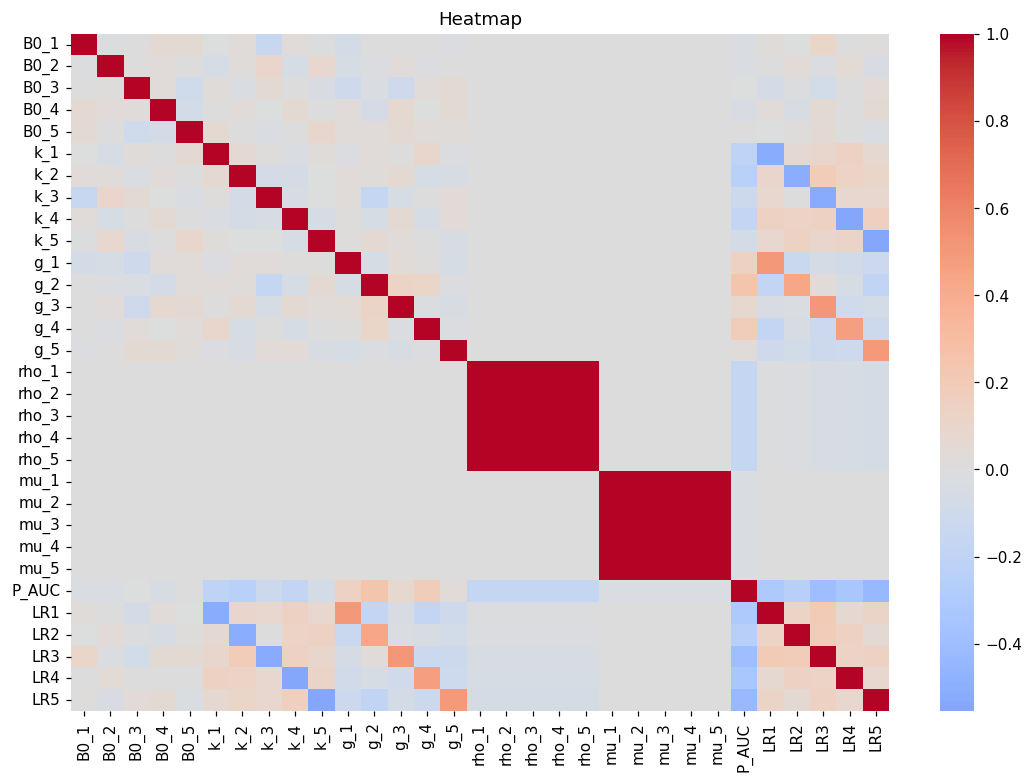

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
df = pd.read_csv("WOUND.csv")

# 顯示基本資訊
print("🔎 資料維度:", df.shape)
print("📋 欄位名稱:", df.columns.tolist())

# 分類欄位
bio_params = [f'B0_{i}' for i in range(1,6)] + [f'k_{i}' for i in range(1,6)] + \
             [f'g_{i}' for i in range(1,6)] + [f'rho_{i}' for i in range(1,6)] + [f'mu_{i}' for i in range(1,6)]
kpi_cols    = ['P_AUC'] + [f'LR{i}' for i in range(1,6)]
target_cols = ['u_max'] + [f'Tthr_{i}' for i in range(1,6)]

# 建立 X / y
X = df[bio_params + kpi_cols].copy()
y = df[target_cols].copy()

# 儲存分好類的資料（方便未來使用）
X.to_csv("X_features.csv", index=False)
y.to_csv("y_targets.csv", index=False)



plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm', center=0)
plt.title("Heatmap")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

# 載入資料
X = pd.read_csv('X_features.csv')
y = pd.read_csv('y_targets.csv')
X = X.dropna(); y = y.loc[X.index]
y = y.dropna(); X = X.loc[y.index]

# 標準化處理
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.15, random_state=42)

histories = {'MLP': {'loss': [], 'val_loss': [], 'r2': []}}

mlp_model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(y.shape[1])
])
mlp_model.compile(optimizer=Adam(1e-4), loss='mse')

class MLPHistoryCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        histories['MLP']['loss'].append(logs['loss'])
        histories['MLP']['val_loss'].append(logs['val_loss'])
        y_pred = self.model.predict(X_test, verbose=0)
        y_pred_inv = y_scaler.inverse_transform(y_pred)
        y_test_inv = y_scaler.inverse_transform(y_test)
        r2 = r2_score(y_test_inv, y_pred_inv)
        histories['MLP']['r2'].append(r2)
        print(f"Epoch {epoch+1:03d} - Loss: {logs['loss']:.2e} - Val Loss: {logs['val_loss']:.2e} - R²: {r2:.4f}")

# 學習率調整函數（每300個epoch將lr減少為原來的0.1倍）
def scheduler(epoch, lr):
    if epoch > 0 and epoch % 300 == 0:
        return lr * 0.1
    return lr

mlp_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1000,
    batch_size=64,
    verbose=0,
    callbacks=[
        MLPHistoryCallback(),
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        LearningRateScheduler(scheduler)
    ]
)
# 用未標準化的資料訓練 Ridge 和 GBDT
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.15, random_state=42)
ridge_model = MultiOutputRegressor(Ridge(alpha=1.0)).fit(X_train_orig, y_train_orig)
ridge_r2 = r2_score(y_test_orig, ridge_model.predict(X_test_orig))

gbdt_model = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100)).fit(X_train_orig, y_train_orig)
gbdt_r2 = r2_score(y_test_orig, gbdt_model.predict(X_test_orig))

# 可視化 loss 和 R²
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(histories['MLP']['loss'], label='Training Loss')
plt.plot(histories['MLP']['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('MLP Training & Validation Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(histories['MLP']['r2'], label='MLP R²')
plt.xlabel('Epoch'); plt.ylabel('R² Score'); plt.title('MLP R² Score over Epochs'); plt.ylim(0, 1); plt.legend()
plt.tight_layout(); plt.show()

# 最終 R² 條狀圖
final_mlp_r2 = histories['MLP']['r2'][-1] if histories['MLP']['r2'] else 0
plt.figure(figsize=(6, 4))
bars = plt.bar(['MLP', 'Ridge', 'GBDT'], [final_mlp_r2, ridge_r2, gbdt_r2],
               color=['skyblue', 'lightgreen', 'salmon'])
for bar, r2 in zip(bars, [final_mlp_r2, ridge_r2, gbdt_r2]):
    plt.text(bar.get_x() + bar.get_width() / 2, min(bar.get_height() + 0.02, 0.98), f"{r2:.3f}", ha='center')
plt.ylabel('R² Score'); plt.title('Final R² Comparison of Models'); plt.ylim(0, 1); plt.show()



C:\Users\jenso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\jenso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.22916e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jenso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.22916e-18): result ma

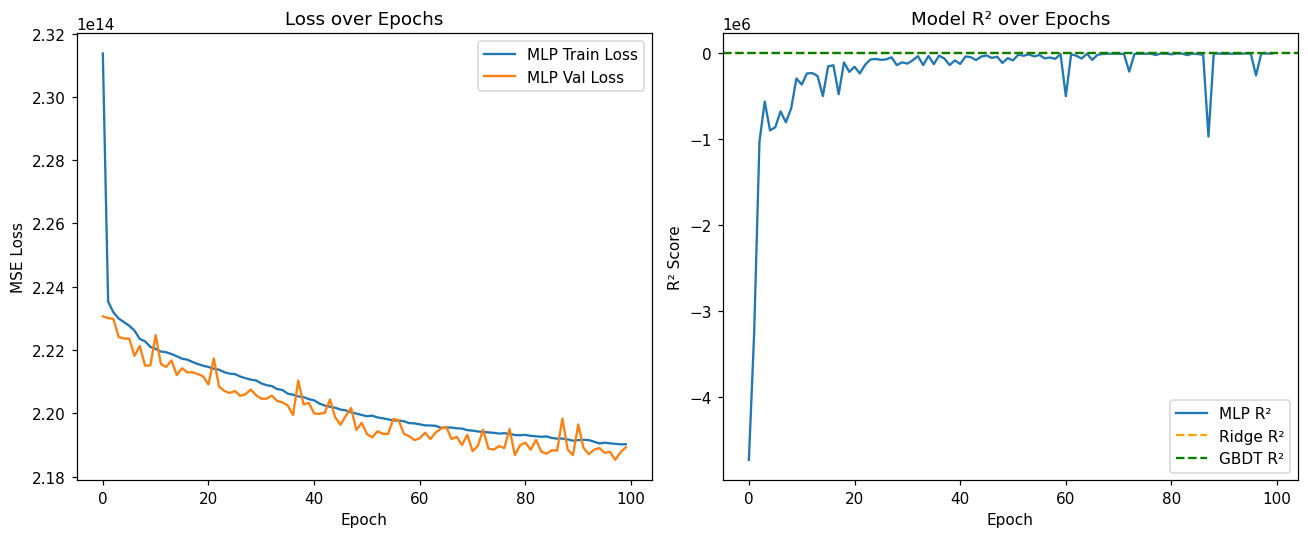

In [9]:
# 8. Plot training losses
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(histories['MLP']['loss'], label='MLP Train Loss')
plt.plot(histories['MLP']['val_loss'], label='MLP Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# 9. Plot R2
plt.subplot(1, 2, 2)
plt.plot(histories['MLP']['r2'], label='MLP R²')
plt.axhline(y=ridge_r2, color='orange', linestyle='--', label='Ridge R²')
plt.axhline(y=gbdt_r2, color='green', linestyle='--', label='GBDT R²')
plt.title('Model R² over Epochs')
plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.legend()

plt.tight_layout()
plt.show()

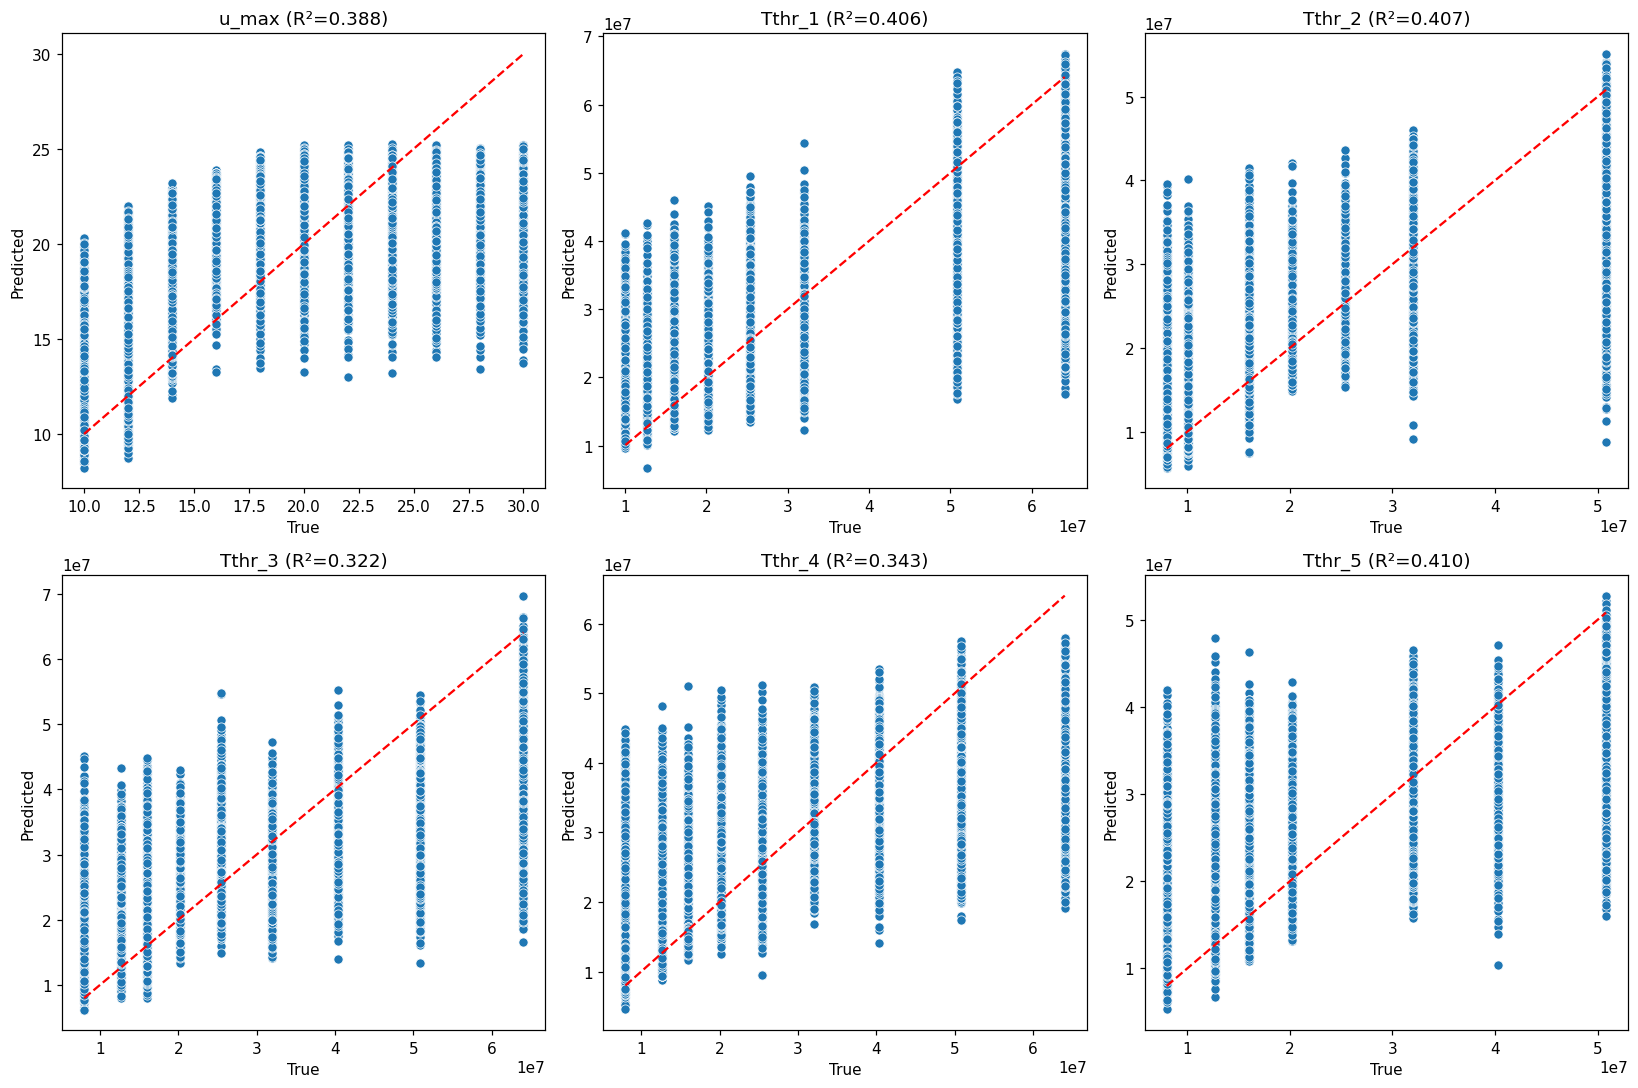

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Load the dataset
X = pd.read_csv('X_features.csv')
y = pd.read_csv('y_targets.csv')

# Drop rows with NaN if any
X = X.dropna()
y = y.loc[X.index]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Train XGBoost as MultiOutputRegressor
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model = MultiOutputRegressor(xgb_base)
xgb_model.fit(X_train, y_train)

# Prediction and Evaluation
y_pred = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred, multioutput='raw_values')
xgb_r2_mean = r2_score(y_test, y_pred)

# Plotting predicted vs actual for each output dimension
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
target_names = y.columns.tolist()

for i, ax in enumerate(axes):
    sns.scatterplot(x=y_test.iloc[:, i], y=y_pred[:, i], ax=ax)
    ax.set_title(f"{target_names[i]} (R²={xgb_r2[i]:.3f})")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
            [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
            'r--')

plt.tight_layout()

plt.show()


In [29]:
def evaluate_xgb_predictions_with_simulation(xgb_model, X_features_df, run_case_func, n_samples=100, random_state=42):
    np.random.seed(random_state)
    sampled = X_features_df.sample(n=n_samples, random_state=random_state)
    predictions = xgb_model.predict(sampled)

    simulated_results = []
    for i in range(n_samples):
        row = sampled.iloc[i]
        B0 = row[[f"B0_{i}" for i in range(1, 6)]].values
        k_arr = row[[f"k_{i}" for i in range(1, 6)]].values
        gamma_arr = row[[f"g_{i}" for i in range(1, 6)]].values
        rho_arr = row[[f"rho_{i}" for i in range(1, 6)]].values
        mu_arr = row[[f"mu_{i}" for i in range(1, 6)]].values

        # 來自模型預測的 control parameters
        u_max = predictions[i][0]
        T_thr = predictions[i][1:6]
        sim_output = run_case_func(B0, k_arr, gamma_arr, rho_arr, mu_arr, u_max, T_thr)

        # ➜ 只保留最後 6 個欄位：P_AUC + LR1~5
        simulated_results.append(sim_output[-6:])

    simulated_results = np.array(simulated_results)
    simulated_df = pd.DataFrame(simulated_results, columns=["P_AUC", "LR1", "LR2", "LR3", "LR4", "LR5"])

    return simulated_df

# === 使用 ===
X_features = pd.read_csv("X_features.csv")
result_df = evaluate_xgb_predictions_with_simulation(
    xgb_model=xgb_model,
    X_features_df=X_features,
    run_case_func=run_case,
    n_samples=100,
    random_state=42
)

# 📊 Summary
print(result_df.describe())

            P_AUC         LR1         LR2         LR3         LR4         LR5
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean     0.092717    1.760255    0.938193    2.366863    0.400677    1.598524
std      0.045177    3.051924    2.652186    3.015246    2.173443    2.989235
min      0.012352   -1.425857   -1.519213   -1.313628   -1.532394   -1.255808
25%      0.057552   -0.837742   -0.898879   -0.751018   -0.979624   -0.895725
50%      0.094750    0.484124   -0.601520    1.746396   -0.727222   -0.162094
75%      0.120395    5.177236    2.187511    6.288504    0.815805    4.707754
max      0.216517    6.553984    6.559259    6.576465    6.575161    6.612085


In [36]:
!pip install catboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 3.4 MB/s eta 0:00:31
    --------------------------------------- 1.8/102.4 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 3.1/102.4 MB 5.3 MB/s eta 0:00:19
   - -------------------------------------- 3.1/102.4 MB 5.3 MB/s eta 0:00:19
   - -------------------------------------- 3.7/102.4 MB 3.8 MB/s eta 0:00:27
   - -------------------------------------- 4.7/102.4 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 6.3/102.4 MB 4.4 MB/s eta 0:00:22
   -- ------------------------------------- 7.1/102.4 MB 4.5 MB/s eta 0:00:22
   --- ------------------------------------ 8.7/102.4 MB 4.8 MB/s eta 0:00:20
   --- ------------------------------------ 10.2/102.4 MB 5.1 MB/s eta 0:00:19


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\jenso\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


0:	learn: 6.2438967	total: 155ms	remaining: 2m 34s
100:	learn: 5.1938347	total: 960ms	remaining: 8.55s
200:	learn: 5.1225837	total: 1.76s	remaining: 6.99s
300:	learn: 5.0696862	total: 2.56s	remaining: 5.95s
400:	learn: 5.0258206	total: 3.37s	remaining: 5.03s
500:	learn: 4.9914288	total: 4.16s	remaining: 4.14s
600:	learn: 4.9617342	total: 4.95s	remaining: 3.28s
700:	learn: 4.9358832	total: 5.76s	remaining: 2.46s
800:	learn: 4.9122632	total: 6.61s	remaining: 1.64s
900:	learn: 4.8917841	total: 7.44s	remaining: 818ms
999:	learn: 4.8718512	total: 8.26s	remaining: 0us
0:	learn: 16478776.9354819	total: 9.73ms	remaining: 9.72s
100:	learn: 14344483.3847937	total: 806ms	remaining: 7.17s
200:	learn: 13869798.7606486	total: 1.6s	remaining: 6.36s
300:	learn: 13526594.6101252	total: 2.4s	remaining: 5.57s
400:	learn: 13265666.0893489	total: 3.3s	remaining: 4.92s
500:	learn: 13053417.3234082	total: 4.15s	remaining: 4.14s
600:	learn: 12862351.9291985	total: 4.98s	remaining: 3.31s
700:	learn: 12713060.7

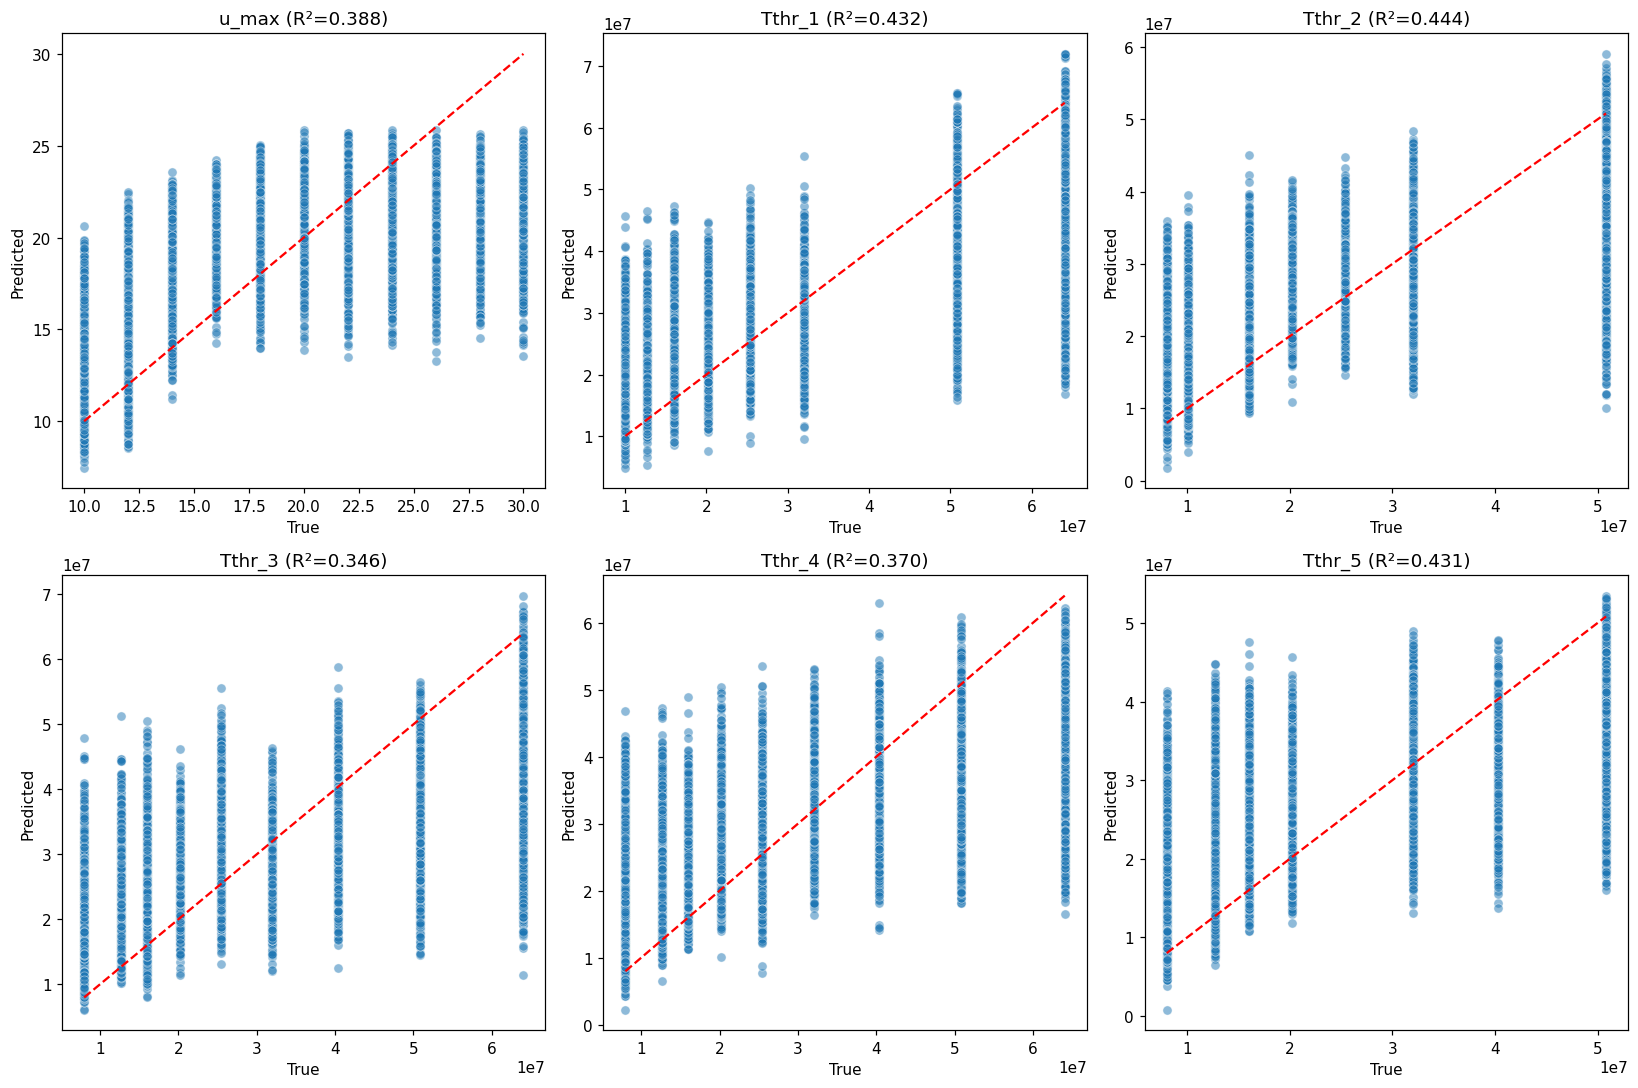

In [37]:
# Re-import everything after runtime reset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
X = pd.read_csv('X_features.csv')
y = pd.read_csv('y_targets.csv')

# Drop NaNs if any
X = X.dropna()
y = y.loc[X.index]

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 3. Initialize CatBoost model
catboost_base = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    early_stopping_rounds=50,
    verbose=100,
    random_state=42,
    task_type="CPU"
)

# 4. Wrap into MultiOutputRegressor
catboost_model = MultiOutputRegressor(catboost_base)
catboost_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = catboost_model.predict(X_test)
r2_per_target = r2_score(y_test, y_pred, multioutput='raw_values')
r2_avg = r2_score(y_test, y_pred)

# 6. Plot true vs pred
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
target_names = y.columns.tolist()

for i, ax in enumerate(axes):
    sns.scatterplot(x=y_test.iloc[:, i], y=y_pred[:, i], ax=ax, alpha=0.5)
    ax.set_title(f"{target_names[i]} (R²={r2_per_target[i]:.3f})")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.plot(
        [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
        [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
        'r--'
    )

plt.tight_layout()
plt.show()




Epoch 001 - Loss: 9.33e-01 - Val Loss: 8.95e-01 - R²: 0.1043
Epoch 002 - Loss: 8.78e-01 - Val Loss: 8.64e-01 - R²: 0.1353
Epoch 003 - Loss: 8.52e-01 - Val Loss: 8.42e-01 - R²: 0.1573
Epoch 004 - Loss: 8.32e-01 - Val Loss: 8.24e-01 - R²: 0.1750
Epoch 005 - Loss: 8.15e-01 - Val Loss: 8.09e-01 - R²: 0.1897
Epoch 006 - Loss: 8.01e-01 - Val Loss: 7.96e-01 - R²: 0.2030
Epoch 007 - Loss: 7.88e-01 - Val Loss: 7.84e-01 - R²: 0.2149
Epoch 008 - Loss: 7.76e-01 - Val Loss: 7.73e-01 - R²: 0.2257
Epoch 009 - Loss: 7.65e-01 - Val Loss: 7.64e-01 - R²: 0.2356
Epoch 010 - Loss: 7.56e-01 - Val Loss: 7.55e-01 - R²: 0.2445
Epoch 011 - Loss: 7.47e-01 - Val Loss: 7.47e-01 - R²: 0.2525
Epoch 012 - Loss: 7.39e-01 - Val Loss: 7.39e-01 - R²: 0.2599
Epoch 013 - Loss: 7.32e-01 - Val Loss: 7.32e-01 - R²: 0.2667
Epoch 014 - Loss: 7.25e-01 - Val Loss: 7.26e-01 - R²: 0.2733
Epoch 015 - Loss: 7.18e-01 - Val Loss: 7.20e-01 - R²: 0.2794
Epoch 016 - Loss: 7.12e-01 - Val Loss: 7.14e-01 - R²: 0.2851
Epoch 017 - Loss: 7.06e-

C:\Users\jenso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.22916e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jenso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.22916e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jenso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.22916e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\jenso\AppD

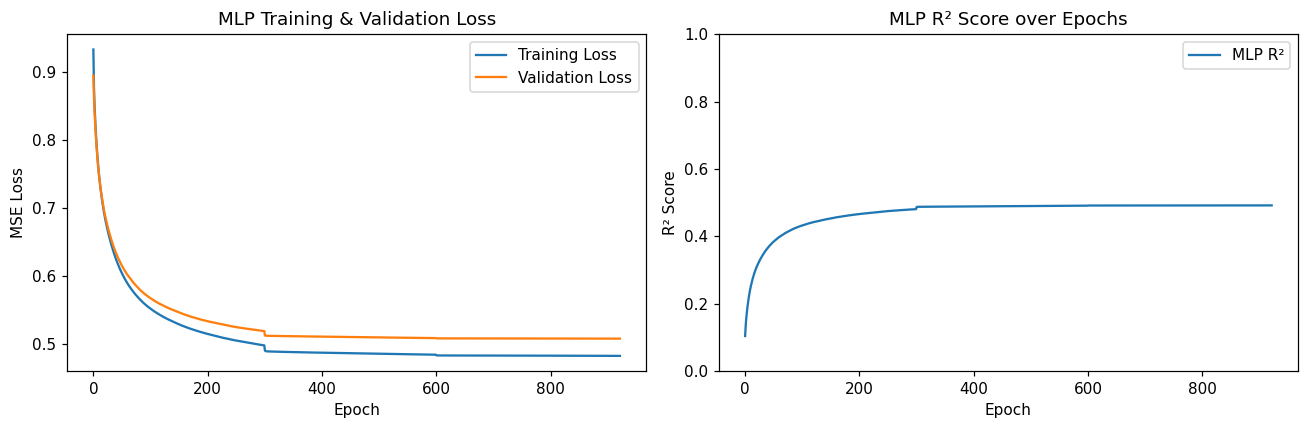

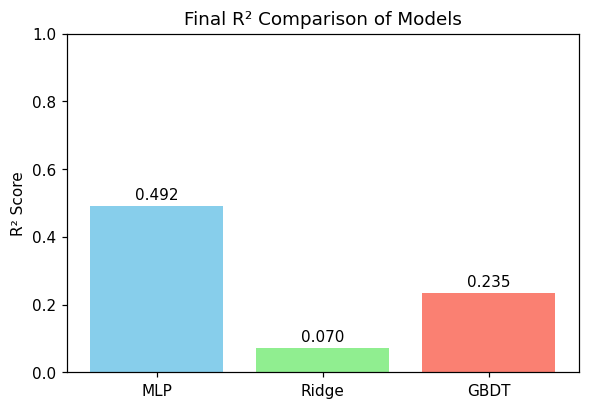

In [51]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

# 載入資料
X = pd.read_csv('X_features.csv')
y = pd.read_csv('y_targets.csv')
X = X.dropna(); y = y.loc[X.index]
y = y.dropna(); X = X.loc[y.index]

# 標準化處理
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.15, random_state=42)

histories = {'MLP': {'loss': [], 'val_loss': [], 'r2': []}}

mlp_model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(y.shape[1])
])
mlp_model.compile(optimizer=Adam(1e-4), loss='mse')

class MLPHistoryCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        histories['MLP']['loss'].append(logs['loss'])
        histories['MLP']['val_loss'].append(logs['val_loss'])
        y_pred = self.model.predict(X_test, verbose=0)
        y_pred_inv = y_scaler.inverse_transform(y_pred)
        y_test_inv = y_scaler.inverse_transform(y_test)
        r2 = r2_score(y_test_inv, y_pred_inv)
        histories['MLP']['r2'].append(r2)
        print(f"Epoch {epoch+1:03d} - Loss: {logs['loss']:.2e} - Val Loss: {logs['val_loss']:.2e} - R²: {r2:.4f}")

# 學習率調整函數（每300個epoch將lr減少為原來的0.1倍）
def scheduler(epoch, lr):
    if epoch > 0 and epoch % 300 == 0:
        return lr * 0.1
    return lr

mlp_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1000,
    batch_size=64,
    verbose=0,
    callbacks=[
        MLPHistoryCallback(),
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        LearningRateScheduler(scheduler)
    ]
)
# 用未標準化的資料訓練 Ridge 和 GBDT
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=0.15, random_state=42)
ridge_model = MultiOutputRegressor(Ridge(alpha=1.0)).fit(X_train_orig, y_train_orig)
ridge_r2 = r2_score(y_test_orig, ridge_model.predict(X_test_orig))

gbdt_model = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100)).fit(X_train_orig, y_train_orig)
gbdt_r2 = r2_score(y_test_orig, gbdt_model.predict(X_test_orig))

# 可視化 loss 和 R²
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(histories['MLP']['loss'], label='Training Loss')
plt.plot(histories['MLP']['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('MLP Training & Validation Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(histories['MLP']['r2'], label='MLP R²')
plt.xlabel('Epoch'); plt.ylabel('R² Score'); plt.title('MLP R² Score over Epochs'); plt.ylim(0, 1); plt.legend()
plt.tight_layout(); plt.show()

# 最終 R² 條狀圖
final_mlp_r2 = histories['MLP']['r2'][-1] if histories['MLP']['r2'] else 0
plt.figure(figsize=(6, 4))
bars = plt.bar(['MLP', 'Ridge', 'GBDT'], [final_mlp_r2, ridge_r2, gbdt_r2],
               color=['skyblue', 'lightgreen', 'salmon'])
for bar, r2 in zip(bars, [final_mlp_r2, ridge_r2, gbdt_r2]):
    plt.text(bar.get_x() + bar.get_width() / 2, min(bar.get_height() + 0.02, 0.98), f"{r2:.3f}", ha='center')
plt.ylabel('R² Score'); plt.title('Final R² Comparison of Models'); plt.ylim(0, 1); plt.show()


In [43]:
# 如果你在 Colab/CPU/GPU 上，请先确保安装了最新 tensorflow：
# !pip install tensorflow --quiet

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, concatenate, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# 自定义 CrossLayer
class CrossLayer(Layer):
    def build(self, input_shape):
        dim = input_shape[0][-1]
        # w: (feature_dim, 1), b: (feature_dim,)
        self.w = self.add_weight(
            name="w", shape=(dim, 1),
            initializer="random_normal", trainable=True
        )
        self.b = self.add_weight(
            name="b", shape=(dim,),
            initializer="zeros", trainable=True
        )
    def call(self, inputs):
        x0, xl = inputs  # x0: 原始输入，xl: 上一层 cross 输出
        # dot: (batch,1)
        dot = tf.matmul(xl, self.w)
        # 逐特征相乘后加 bias，再加 xl
        return x0 * dot + self.b + xl

# 每 epoch 打印 MSE 与 R²
class R2Logger(Callback):
    def __init__(self, X_val, y_val_log):
        super().__init__()
        self.X_val = X_val
        self.y_val_log = y_val_log
        self.r2s = []
    def on_epoch_end(self, epoch, logs=None):
        y_pred_log = self.model.predict(self.X_val, verbose=0)
        # 还原真实值
        y_true = np.expm1(self.y_val_log)
        y_pred = np.expm1(y_pred_log)
        r2 = r2_score(y_true, y_pred)
        self.r2s.append(r2)
        print(f"Epoch {epoch+1:04d} – "
              f"Train MSE: {logs['loss']:.2e} – "
              f"Valid MSE: {logs['val_loss']:.2e} – "
              f"R²: {r2:.4f}")

# 读数据
X = pd.read_csv("X_features.csv").dropna()
y = pd.read_csv("y_targets.csv").loc[X.index]
y_log = np.log1p(y.values)  # log1p transform

# 拆分
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X.values, y_log, test_size=0.15, random_state=42
)

# 标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

# 构建 DCN 模型
def build_dcn(input_dim, cross_layers=3, deep_units=[256,128,64], dropout_rate=0.3):
    x0 = Input(shape=(input_dim,), name="features")
    # Cross Network
    xl = x0
    for _ in range(cross_layers):
        xl = CrossLayer()([x0, xl])
    # Deep Network
    xd = x0
    for units in deep_units:
        xd = Dense(units, activation="relu")(xd)
        xd = Dropout(dropout_rate)(xd)
    # 合并
    x = concatenate([xl, xd])
    out = Dense(6, activation=None, name="output")(x)
    return Model(inputs=x0, outputs=out)

tf.random.set_seed(42)
model = build_dcn(input_dim=X_train.shape[1])
model.compile(optimizer=Adam(1e-3), loss="mse")

# 回调：打印＋EarlyStop＋LR Scheduler
r2_logger = R2Logger(X_val, y_val_log)
callbacks = [
    r2_logger,
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, verbose=1)
]

# 训练
history = model.fit(
    X_train, y_train_log,
    validation_data=(X_val, y_val_log),
    epochs=500,
    batch_size=1024,
    callbacks=callbacks,
    verbose=0  # 训练过程由 R2Logger 打印
)

# 最终计算
y_pred_log = model.predict(X_val, verbose=0)
final_r2 = r2_score(np.expm1(y_val_log), np.expm1(y_pred_log))
print(f"\n Final R² = {final_r2:.4f}")


Epoch 0001 – Train MSE: 3.57e+01 – Valid MSE: 1.36e+00 – R²: -9.9460
Epoch 0002 – Train MSE: 7.99e+00 – Valid MSE: 8.74e-01 – R²: -3.1227
Epoch 0003 – Train MSE: 4.98e+00 – Valid MSE: 6.83e-01 – R²: -0.7656
Epoch 0004 – Train MSE: 2.66e+00 – Valid MSE: 6.05e-01 – R²: -0.6496
Epoch 0005 – Train MSE: 1.11e+00 – Valid MSE: 6.57e-01 – R²: -0.7500
Epoch 0006 – Train MSE: 5.14e-01 – Valid MSE: 5.28e-01 – R²: -0.5982
Epoch 0007 – Train MSE: 3.74e-01 – Valid MSE: 3.98e-01 – R²: -0.3739
Epoch 0008 – Train MSE: 3.41e-01 – Valid MSE: 3.47e-01 – R²: -0.2420
Epoch 0009 – Train MSE: 3.30e-01 – Valid MSE: 3.27e-01 – R²: -0.1677
Epoch 0010 – Train MSE: 3.25e-01 – Valid MSE: 3.21e-01 – R²: -0.1396
Epoch 0011 – Train MSE: 3.20e-01 – Valid MSE: 3.15e-01 – R²: -0.1092
Epoch 0012 – Train MSE: 3.18e-01 – Valid MSE: 3.13e-01 – R²: -0.0908
Epoch 0013 – Train MSE: 3.16e-01 – Valid MSE: 3.10e-01 – R²: -0.0732
Epoch 0014 – Train MSE: 3.13e-01 – Valid MSE: 3.09e-01 – R²: -0.0660
Epoch 0015 – Train MSE: 3.12e-01 –

In [55]:
# 如果你在 Colab/GPU 上，请先确保安装依赖：
# !pip install xgboost tensorflow scikit-learn --quiet

# 如果在 Colab/GPU 上，请先安装依赖：
# !pip install xgboost tensorflow scikit-learn --quiet

import numpy as np
import pandas as pd
from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import r2_score
from sklearn.multioutput       import MultiOutputRegressor
from xgboost                   import XGBRegressor
import tensorflow as tf
from tensorflow.keras          import Input, Model
from tensorflow.keras.layers   import Dense, Dropout, concatenate, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import Callback, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ─── 1) 载入 & 预处理 ───────────────────────────────────────────────
X_df = pd.read_csv("X_features.csv").dropna()
y_df = pd.read_csv("y_targets.csv").loc[X_df.index]

X = X_df.values
y_log = np.log1p(y_df.values)   # 对 targets 做 log1p

# 划分训练/验证
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.15, random_state=42
)

# 标准化 features
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)


# ─── 2) 定义 DCN 基学习器 ───────────────────────────────────────────
class CrossLayer(Layer):
    def build(self, input_shape):
        dim = input_shape[0][-1]
        # 注意必须用 name=, 否则 Keras 识别 pos arg 为 shape
        self.w = self.add_weight(name="w", shape=(dim,1),
                                 initializer="random_normal", trainable=True)
        self.b = self.add_weight(name="b", shape=(dim,),
                                 initializer="zeros", trainable=True)
    def call(self, inputs):
        x0, xl = inputs
        dot = tf.matmul(xl, self.w)       # (batch,1)
        return x0 * dot + self.b + xl

def build_dcn(input_dim, output_dim,
              cross_layers=3, deep_units=[256,128,64], dropout_rate=0.3):
    x0 = Input(shape=(input_dim,), name="features")
    # Cross network
    xl = x0
    for _ in range(cross_layers):
        xl = CrossLayer()([x0, xl])
    # Deep network
    xd = x0
    for units in deep_units:
        xd = Dense(units, activation="relu")(xd)
        xd = Dropout(dropout_rate)(xd)
    # 合并 & 输出
    merged = concatenate([xl, xd])
    out = Dense(output_dim, activation=None, name="output")(merged)
    return Model(x0, out)

# R² 实时打印回调
class R2Logger(Callback):
    def __init__(self, X_val, y_val_log, name="Model"):
        super().__init__()
        self.X_val, self.y_val_log, self.name = X_val, y_val_log, name
    def on_epoch_end(self, epoch, logs=None):
        pred_log = self.model.predict(self.X_val, verbose=0)
        y_true   = np.expm1(self.y_val_log)
        y_pred   = np.expm1(pred_log)
        r2 = r2_score(y_true, y_pred)
        print(f"{self.name} ▶ epoch {epoch+1:03d} "
              f"- loss {logs['loss']:.4e} "
              f"- val_loss {logs['val_loss']:.4e} "
              f"- val_R² {r2:.4f}")

# 实例化 & 训练 DCN
tf.random.set_seed(42)
dcn = build_dcn(X_train.shape[1], y_train_log.shape[1])
dcn.compile(optimizer=Adam(1e-3), loss="mse")

print("\n▶▶▶ 训练 DCN …")
dcn.fit(
    X_train, y_train_log,
    validation_data=(X_val, y_val_log),
    epochs=400,
    batch_size=256,
    callbacks=[
        R2Logger(X_val, y_val_log, name="DCN"),
        EarlyStopping("val_loss", patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau("val_loss", factor=0.5, patience=10, verbose=1)
    ],
    verbose=0
)

pred_train_dcn = dcn.predict(X_train)
pred_val_dcn   = dcn.predict(X_val)


# ─── 3) 定义 XGBoost 基学习器 ───────────────────────────────────────
print("\n▶▶▶ 训练 XGBoost …")
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb = MultiOutputRegressor(xgb_base)
xgb.fit(X_train, y_train_log)

pred_train_xgb = xgb.predict(X_train)
pred_val_xgb   = xgb.predict(X_val)


# ─── 4) 构造元特征 & 训练 Meta Learner ───────────────────────────────
meta_train = np.hstack([pred_train_dcn, pred_train_xgb])  # (N_train, 12)
meta_val   = np.hstack([pred_val_dcn,   pred_val_xgb])    # (N_val,   12)

inp = Input(shape=(meta_train.shape[1],))
h = Dense(64, activation="relu")(inp)
h = Dense(32, activation="relu")(h)
out = Dense(y_train_log.shape[1], activation=None)(h)
meta_mlp = Model(inp, out)
meta_mlp.compile(optimizer=Adam(1e-3), loss="mse")

print("\n▶▶▶ 训练 Meta Learner …")
meta_mlp.fit(
    meta_train, y_train_log,
    validation_data=(meta_val, y_val_log),
    epochs=100,
    batch_size=64,
    callbacks=[
        R2Logger(meta_val, y_val_log, name="Meta-MLP"),
        EarlyStopping("val_loss", patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau("val_loss", factor=0.5, patience=5, verbose=1)
    ],
    verbose=0
)

# ─── 5) 最终评估 ───────────────────────────────────────────────────
pred_meta_log = meta_mlp.predict(meta_val)
pred_meta     = np.expm1(pred_meta_log)
true          = np.expm1(y_val_log)

r2_scores = [r2_score(true[:,i], pred_meta[:,i]) for i in range(true.shape[1])]
print("\n▶▶▶ Stacking Ensemble 各输出 R²：")
for idx, val in enumerate(r2_scores, start=1):
    print(f"  target{idx}: R² = {val:.4f}")
print("  平均 R² =", np.mean(r2_scores))



▶▶▶ 训练 DCN …
DCN ▶ epoch 001 - loss 1.2990e+01 - val_loss 5.7546e-01 - val_R² -0.6626
DCN ▶ epoch 002 - loss 6.9077e-01 - val_loss 3.8087e-01 - val_R² -0.3283
DCN ▶ epoch 003 - loss 3.2832e-01 - val_loss 3.2229e-01 - val_R² -0.1306
DCN ▶ epoch 004 - loss 3.1793e-01 - val_loss 3.1506e-01 - val_R² -0.0767
DCN ▶ epoch 005 - loss 3.1342e-01 - val_loss 3.0994e-01 - val_R² -0.0466
DCN ▶ epoch 006 - loss 3.1027e-01 - val_loss 3.0610e-01 - val_R² -0.0361
DCN ▶ epoch 007 - loss 3.0603e-01 - val_loss 2.9953e-01 - val_R² -0.0212
DCN ▶ epoch 008 - loss 3.0156e-01 - val_loss 2.9292e-01 - val_R² 0.0041
DCN ▶ epoch 009 - loss 2.9669e-01 - val_loss 2.8605e-01 - val_R² 0.0262
DCN ▶ epoch 010 - loss 2.9010e-01 - val_loss 2.7573e-01 - val_R² 0.0496
DCN ▶ epoch 011 - loss 2.8238e-01 - val_loss 2.6270e-01 - val_R² 0.0931
DCN ▶ epoch 012 - loss 2.7218e-01 - val_loss 2.4866e-01 - val_R² 0.1365
DCN ▶ epoch 013 - loss 2.6177e-01 - val_loss 2.3564e-01 - val_R² 0.1760
DCN ▶ epoch 014 - loss 2.5284e-01 - val_los

▶▶▶ 训练 XGBoost …
▶ 訓練 target 1
[0]	validation_0-rmse:0.31860
[100]	validation_0-rmse:0.22135
[200]	validation_0-rmse:0.20938
[300]	validation_0-rmse:0.20189
[400]	validation_0-rmse:0.19640
[500]	validation_0-rmse:0.19178
[600]	validation_0-rmse:0.18767
[700]	validation_0-rmse:0.18413
[800]	validation_0-rmse:0.18103
[900]	validation_0-rmse:0.17823
[1000]	validation_0-rmse:0.17573
[1100]	validation_0-rmse:0.17329
[1200]	validation_0-rmse:0.17111
[1300]	validation_0-rmse:0.16916
[1400]	validation_0-rmse:0.16736
[1500]	validation_0-rmse:0.16565
[1600]	validation_0-rmse:0.16414
[1700]	validation_0-rmse:0.16277
[1800]	validation_0-rmse:0.16140
[1900]	validation_0-rmse:0.16010
[1999]	validation_0-rmse:0.15899
▶ 訓練 target 2
[0]	validation_0-rmse:0.54924
[100]	validation_0-rmse:0.38774
[200]	validation_0-rmse:0.36777
[300]	validation_0-rmse:0.35929
[400]	validation_0-rmse:0.35473
[500]	validation_0-rmse:0.35264
[600]	validation_0-rmse:0.35127
[700]	validation_0-rmse:0.35103
[800]	validation_0-rmse:0.35114
[900]	validation_0-rmse:0.35127
[1000]	validation_0-rmse:0.35173
[1100]	validation_0-rmse:0.35224
[1200]	validation_0-rmse:0.35292
[1300]	validation_0-rmse:0.35390
[1400]	validation_0-rmse:0.35477
[1500]	validation_0-rmse:0.35578
[1600]	validation_0-rmse:0.35677
[1700]	validation_0-rmse:0.35775
[1800]	validation_0-rmse:0.35856
[1900]	validation_0-rmse:0.35944
[1999]	validation_0-rmse:0.36024
▶ 訓練 target 3
[0]	validation_0-rmse:0.58964
[100]	validation_0-rmse:0.40108
[200]	validation_0-rmse:0.37009
[300]	validation_0-rmse:0.35516
[400]	validation_0-rmse:0.34584
[500]	validation_0-rmse:0.33957
[600]	validation_0-rmse:0.33491
[700]	validation_0-rmse:0.33155
[800]	validation_0-rmse:0.32888
[900]	validation_0-rmse:0.32694
[1000]	validation_0-rmse:0.32554
[1100]	validation_0-rmse:0.32458
[1200]	validation_0-rmse:0.32362
[1300]	validation_0-rmse:0.32298
[1400]	validation_0-rmse:0.32256
[1500]	validation_0-rmse:0.32248
[1600]	validation_0-rmse:0.32228
[1700]	validation_0-rmse:0.32213
[1800]	validation_0-rmse:0.32222
[1900]	validation_0-rmse:0.32224
[1999]	validation_0-rmse:0.32235
▶ 訓練 target 4
[0]	validation_0-rmse:0.61389
[100]	validation_0-rmse:0.45276
[200]	validation_0-rmse:0.42394
[300]	validation_0-rmse:0.41132
[400]	validation_0-rmse:0.40355
[500]	validation_0-rmse:0.39764
[600]	validation_0-rmse:0.39359
[700]	validation_0-rmse:0.39078
[800]	validation_0-rmse:0.38861
[900]	validation_0-rmse:0.38696
[1000]	validation_0-rmse:0.38606
[1100]	validation_0-rmse:0.38513
[1200]	validation_0-rmse:0.38452
[1300]	validation_0-rmse:0.38418
[1400]	validation_0-rmse:0.38395
[1500]	validation_0-rmse:0.38378
[1600]	validation_0-rmse:0.38363
[1700]	validation_0-rmse:0.38378
[1800]	validation_0-rmse:0.38397
[1900]	validation_0-rmse:0.38419
[1999]	validation_0-rmse:0.38453
▶ 訓練 target 5
[0]	validation_0-rmse:0.60592
[100]	validation_0-rmse:0.44624
[200]	validation_0-rmse:0.42051
[300]	validation_0-rmse:0.40724
[400]	validation_0-rmse:0.39875
[500]	validation_0-rmse:0.39269
[600]	validation_0-rmse:0.38854
[700]	validation_0-rmse:0.38573
[800]	validation_0-rmse:0.38383
[900]	validation_0-rmse:0.38243
[1000]	validation_0-rmse:0.38175
[1100]	validation_0-rmse:0.38127
[1200]	validation_0-rmse:0.38102
[1300]	validation_0-rmse:0.38097
[1400]	validation_0-rmse:0.38109
[1500]	validation_0-rmse:0.38144
[1600]	validation_0-rmse:0.38175
[1700]	validation_0-rmse:0.38226
[1800]	validation_0-rmse:0.38275
[1900]	validation_0-rmse:0.38335
[1999]	validation_0-rmse:0.38385
▶ 訓練 target 6
[0]	validation_0-rmse:0.60713
[100]	validation_0-rmse:0.42341
[200]	validation_0-rmse:0.40017
[300]	validation_0-rmse:0.38863
[400]	validation_0-rmse:0.38178
[500]	validation_0-rmse:0.37709
[600]	validation_0-rmse:0.37387
[700]	validation_0-rmse:0.37201
[800]	validation_0-rmse:0.37068
[900]	validation_0-rmse:0.36984
[1000]	validation_0-rmse:0.36936
[1100]	validation_0-rmse:0.36908
[1200]	validation_0-rmse:0.36899
[1300]	validation_0-rmse:0.36919
[1400]	validation_0-rmse:0.36936
[1500]	validation_0-rmse:0.36978
[1600]	validation_0-rmse:0.37022
[1700]	validation_0-rmse:0.37058
[1800]	validation_0-rmse:0.37117
[1900]	validation_0-rmse:0.37166
[1999]	validation_0-rmse:0.37244